# Dataset preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [2]:
gates_counts = pd.read_csv('files/extracted_info.csv')
gates_counts

,NAME,ALL_GATES,USED_GATES,IDA,INVA,AND2,OR2,XOR2,NAND2,NOR2,...,WSS,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX
0,mult8_cgp14ep_ep13107_wc0_2_rcam,320,319,0,0,167,48,104,0,0,...,508899,0.9624,0.0721,39,7,175,16,64,-32,201
1,mult8_cgp14ep_ep13107_wc0_rcam,320,320,0,0,168,48,104,0,0,...,525281,0.9656,0.0750,39,7,176,16,64,-32,203
2,mult8_cgp14ep_ep13107_wc0_wtmcla,490,381,0,2,203,66,110,0,0,...,521724,0.9528,0.0630,23,7,212,23,64,-16,205
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,347,325,0,4,165,53,103,0,0,...,465970,0.9508,0.0708,25,6,173,19,64,-19,185
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,347,328,0,4,167,53,104,0,0,...,506924,0.9634,0.0732,25,6,175,20,64,-19,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24901,mult8_cgp14ep_ep65536_wc9_csamrca,320,300,0,1,155,47,96,0,0,...,238839,0.9600,0.0267,28,3,163,16,59,-25,182
24902,mult8_cgp14ep_ep65536_wc9_rcam,320,297,0,0,155,45,97,0,0,...,1041397,0.9697,0.0943,36,8,163,16,58,-28,182
24903,mult8_cgp14ep_ep65536_wc9_wtmcla,490,336,0,0,178,58,100,0,0,...,497283,0.9613,0.0268,21,5,186,18,59,-16,186
24904,mult8_cgp14ep_ep65536_wc9_wtmcsa,418,346,0,6,178,57,105,0,0,...,260478,0.9277,0.0231,24,5,186,22,58,-19,193


In [3]:
json_data = pd.read_csv('files/json_data.csv')
json_data.columns = ['NAME', 'CELLS_JSON', 'SEED', 'MAE', 'WCE', 'WCRE', 'PDK45_AREA', 'PDK45_DELAY', 'PDK45_POWER', 'LEVELS']
json_data

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS
0,mult8_cgp14ep_ep13107_wc0_2_rcam,319,rcam,0.00000,0,0.000000,746.187006,2.06,415800.0,39
1,mult8_cgp14ep_ep13107_wc0_rcam,320,rcam,0.00000,0,0.000000,742.901906,2.04,413300.0,39
2,mult8_cgp14ep_ep13107_wc0_wtmcla,381,wtm_cla,0.00000,0,0.000000,853.187400,1.07,495500.0,23
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,325,csam_csa,35.63379,1000,252.631579,746.187003,1.49,414200.0,25
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,328,csam_csa,32.45898,1008,198.941799,767.774805,1.52,412000.0,25
...,...,...,...,...,...,...,...,...,...,...
24907,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000,705.827206,1.40,386900.0,28
24908,mult8_cgp14ep_ep65536_wc9_rcam,297,rcam,3.16406,9,100.000000,669.221806,1.87,395400.0,37
24909,mult8_cgp14ep_ep65536_wc9_wtmcla,336,wtm_cla,2.79688,9,350.000000,769.182700,1.39,438300.0,22
24910,mult8_cgp14ep_ep65536_wc9_wtmcsa,346,wtm_csa,3.15625,9,100.000000,786.546799,1.31,443800.0,24


In [4]:
df = pd.merge(json_data, gates_counts, left_on='NAME', right_on='NAME', how='inner')
df

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS,...,WSS,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX
0,mult8_cgp14ep_ep13107_wc0_2_rcam,319,rcam,0.00000,0,0.000000,746.187006,2.06,415800.0,39,...,508899,0.9624,0.0721,39,7,175,16,64,-32,201
1,mult8_cgp14ep_ep13107_wc0_rcam,320,rcam,0.00000,0,0.000000,742.901906,2.04,413300.0,39,...,525281,0.9656,0.0750,39,7,176,16,64,-32,203
2,mult8_cgp14ep_ep13107_wc0_wtmcla,381,wtm_cla,0.00000,0,0.000000,853.187400,1.07,495500.0,23,...,521724,0.9528,0.0630,23,7,212,23,64,-16,205
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,325,csam_csa,35.63379,1000,252.631579,746.187003,1.49,414200.0,25,...,465970,0.9508,0.0708,25,6,173,19,64,-19,185
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,328,csam_csa,32.45898,1008,198.941799,767.774805,1.52,412000.0,25,...,506924,0.9634,0.0732,25,6,175,20,64,-19,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24901,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000,705.827206,1.40,386900.0,28,...,238839,0.9600,0.0267,28,3,163,16,59,-25,182
24902,mult8_cgp14ep_ep65536_wc9_rcam,297,rcam,3.16406,9,100.000000,669.221806,1.87,395400.0,37,...,1041397,0.9697,0.0943,36,8,163,16,58,-28,182
24903,mult8_cgp14ep_ep65536_wc9_wtmcla,336,wtm_cla,2.79688,9,350.000000,769.182700,1.39,438300.0,22,...,497283,0.9613,0.0268,21,5,186,18,59,-16,186
24904,mult8_cgp14ep_ep65536_wc9_wtmcsa,346,wtm_csa,3.15625,9,100.000000,786.546799,1.31,443800.0,24,...,260478,0.9277,0.0231,24,5,186,22,58,-19,193


In [5]:
df_missing = pd.merge(json_data, gates_counts, left_on='NAME', right_on='NAME', how='outer', indicator=True)
df_missing[df_missing['_merge'] != 'both']

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS,...,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX,_merge
24583,mult8_cgp14ep_ep65536_wc65025_csamcsa,0,csam_csa,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24584,mult8_cgp14ep_ep65536_wc65025_csamrca,0,csam_rca,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24585,mult8_cgp14ep_ep65536_wc65025_rcam,0,rcam,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24586,mult8_cgp14ep_ep65536_wc65025_wtmcla,0,wtm_cla,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24587,mult8_cgp14ep_ep65536_wc65025_wtmcsa,0,wtm_csa,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24588,mult8_cgp14ep_ep65536_wc65025_wtmrca,0,wtm_rca,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [6]:
df.drop(columns=['LONGEST PATH'], inplace=True)
df.shape

(24906, 32)

# Dataset analysis

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24906 entries, 0 to 24905
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NAME               24906 non-null  object 
 1   CELLS_JSON         24906 non-null  int64  
 2   SEED               24906 non-null  object 
 3   MAE                24906 non-null  float64
 4   WCE                24906 non-null  int64  
 5   WCRE               24906 non-null  float64
 6   PDK45_AREA         24906 non-null  float64
 7   PDK45_DELAY        24906 non-null  float64
 8   PDK45_POWER        24906 non-null  float64
 9   LEVELS             24906 non-null  int64  
 10  ALL_GATES          24906 non-null  int64  
 11  USED_GATES         24906 non-null  int64  
 12  IDA                24906 non-null  int64  
 13  INVA               24906 non-null  int64  
 14  AND2               24906 non-null  int64  
 15  OR2                24906 non-null  int64  
 16  XOR2               249

In [8]:
# Handling missing values
df.isnull().sum()

NAME                 0
CELLS_JSON           0
SEED                 0
MAE                  0
WCE                  0
WCRE                 0
PDK45_AREA           0
PDK45_DELAY          0
PDK45_POWER          0
LEVELS               0
ALL_GATES            0
USED_GATES           0
IDA                  0
INVA                 0
AND2                 0
OR2                  0
XOR2                 0
NAND2                0
NOR2                 0
XNOR2                0
TOTAL_AREA           0
SHARING_FACTOR       0
WSS                  0
LSB%                 0
MSB%                 0
GLOBAL_MAX_DEPTH     0
MSB_MAX_DEPTH        0
MAX_FANOUT           0
GATES_FANOUT_GT_3    0
MAX_WIDTH            0
DEPTH_SKEW           0
CONGESTION_INDEX     0
dtype: int64

In [9]:
# Check for duplicates
df.duplicated().sum()

0

In [10]:
# Show unique values in "SEED" column and their counts
df['SEED'].value_counts()

SEED
wtm_csa     4218
csam_csa    4202
wtm_cla     4200
csam_rca    4140
rcam        4077
wtm_rca     4069
Name: count, dtype: int64

In [11]:
# Summary statistics
df.describe()

,CELLS_JSON,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS,ALL_GATES,USED_GATES,...,WSS,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX
count,24906.000000,24906.000000,24906.000000,2.490600e+04,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,...,2.490600e+04,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000
mean,242.173011,763.627001,5267.406810,1.042279e+03,572.148190,1.210956,300996.048613,22.766442,371.943909,242.173011,...,5.298362e+05,0.819006,0.115571,22.417771,5.527704,134.022485,16.051634,53.837549,-16.687304,109.681402
std,86.251645,1673.129553,9302.001263,9.659348e+03,196.568972,0.408615,124982.919375,7.375686,62.869858,86.251645,...,9.239040e+05,0.225793,0.151780,7.463430,3.777518,45.546985,3.826479,14.107134,7.844291,67.678550
min,1.000000,0.000000,0.000000,0.000000e+00,2.346500,0.040000,301.750000,1.000000,320.000000,1.000000,...,1.000000e+00,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,-35.000000,0.000000
25%,194.000000,15.508177,100.000000,1.000000e+02,474.462295,1.030000,227325.000000,19.000000,320.000000,194.000000,...,2.097722e+05,0.799300,0.053200,19.000000,4.000000,109.000000,15.000000,47.000000,-22.000000,48.000000
50%,272.000000,109.633910,856.000000,1.777778e+02,644.348904,1.270000,352700.000000,24.000000,347.000000,272.000000,...,3.305240e+05,0.918900,0.068300,23.000000,5.000000,150.000000,16.000000,61.000000,-17.000000,125.000000
75%,307.000000,646.066253,5666.000000,3.444444e+02,714.743903,1.430000,396800.000000,27.000000,418.000000,307.000000,...,4.429720e+05,0.957800,0.092800,27.000000,6.000000,168.000000,18.000000,64.000000,-13.000000,168.000000
max,381.000000,16162.875000,64770.000000,1.016700e+06,954.556194,2.360000,532900.000000,40.000000,490.000000,381.000000,...,1.274368e+07,1.000000,1.000000,40.000000,38.000000,212.000000,27.000000,66.000000,4.000000,267.000000


In [12]:
fast_features = ['ALL_GATES','USED_GATES', 'CELLS_JSON', 'LEVELS', 'IDA', 'INVA', 'AND2', 'OR2', 'XOR2', 'NAND2', 'NOR2', 'XNOR2', 'TOTAL_AREA', 
                 'WSS', 'LSB%', 'MSB%', 'GLOBAL_MAX_DEPTH', 'MSB_MAX_DEPTH', 'MAX_FANOUT', 'GATES_FANOUT_GT_3', 'MAX_WIDTH', 'DEPTH_SKEW', 'CONGESTION_INDEX']
slow_targets = ['MAE', 'WCE', 'WCRE', 'PDK45_AREA', 'PDK45_DELAY', 'PDK45_POWER']
error_targets = ['MAE', 'WCE', 'WCRE']

# AREA - POWER analysis

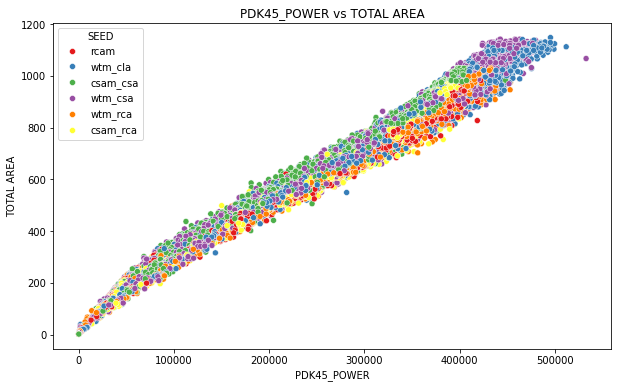

In [13]:
# Scatter plot of PDK45_POWER vs TOTAL AREA with SEED as hue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PDK45_POWER', y='TOTAL_AREA', hue='SEED', palette='Set1')
plt.title('PDK45_POWER vs TOTAL AREA')
plt.xlabel('PDK45_POWER')
plt.ylabel('TOTAL AREA')
plt.legend(title='SEED')
plt.show()

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


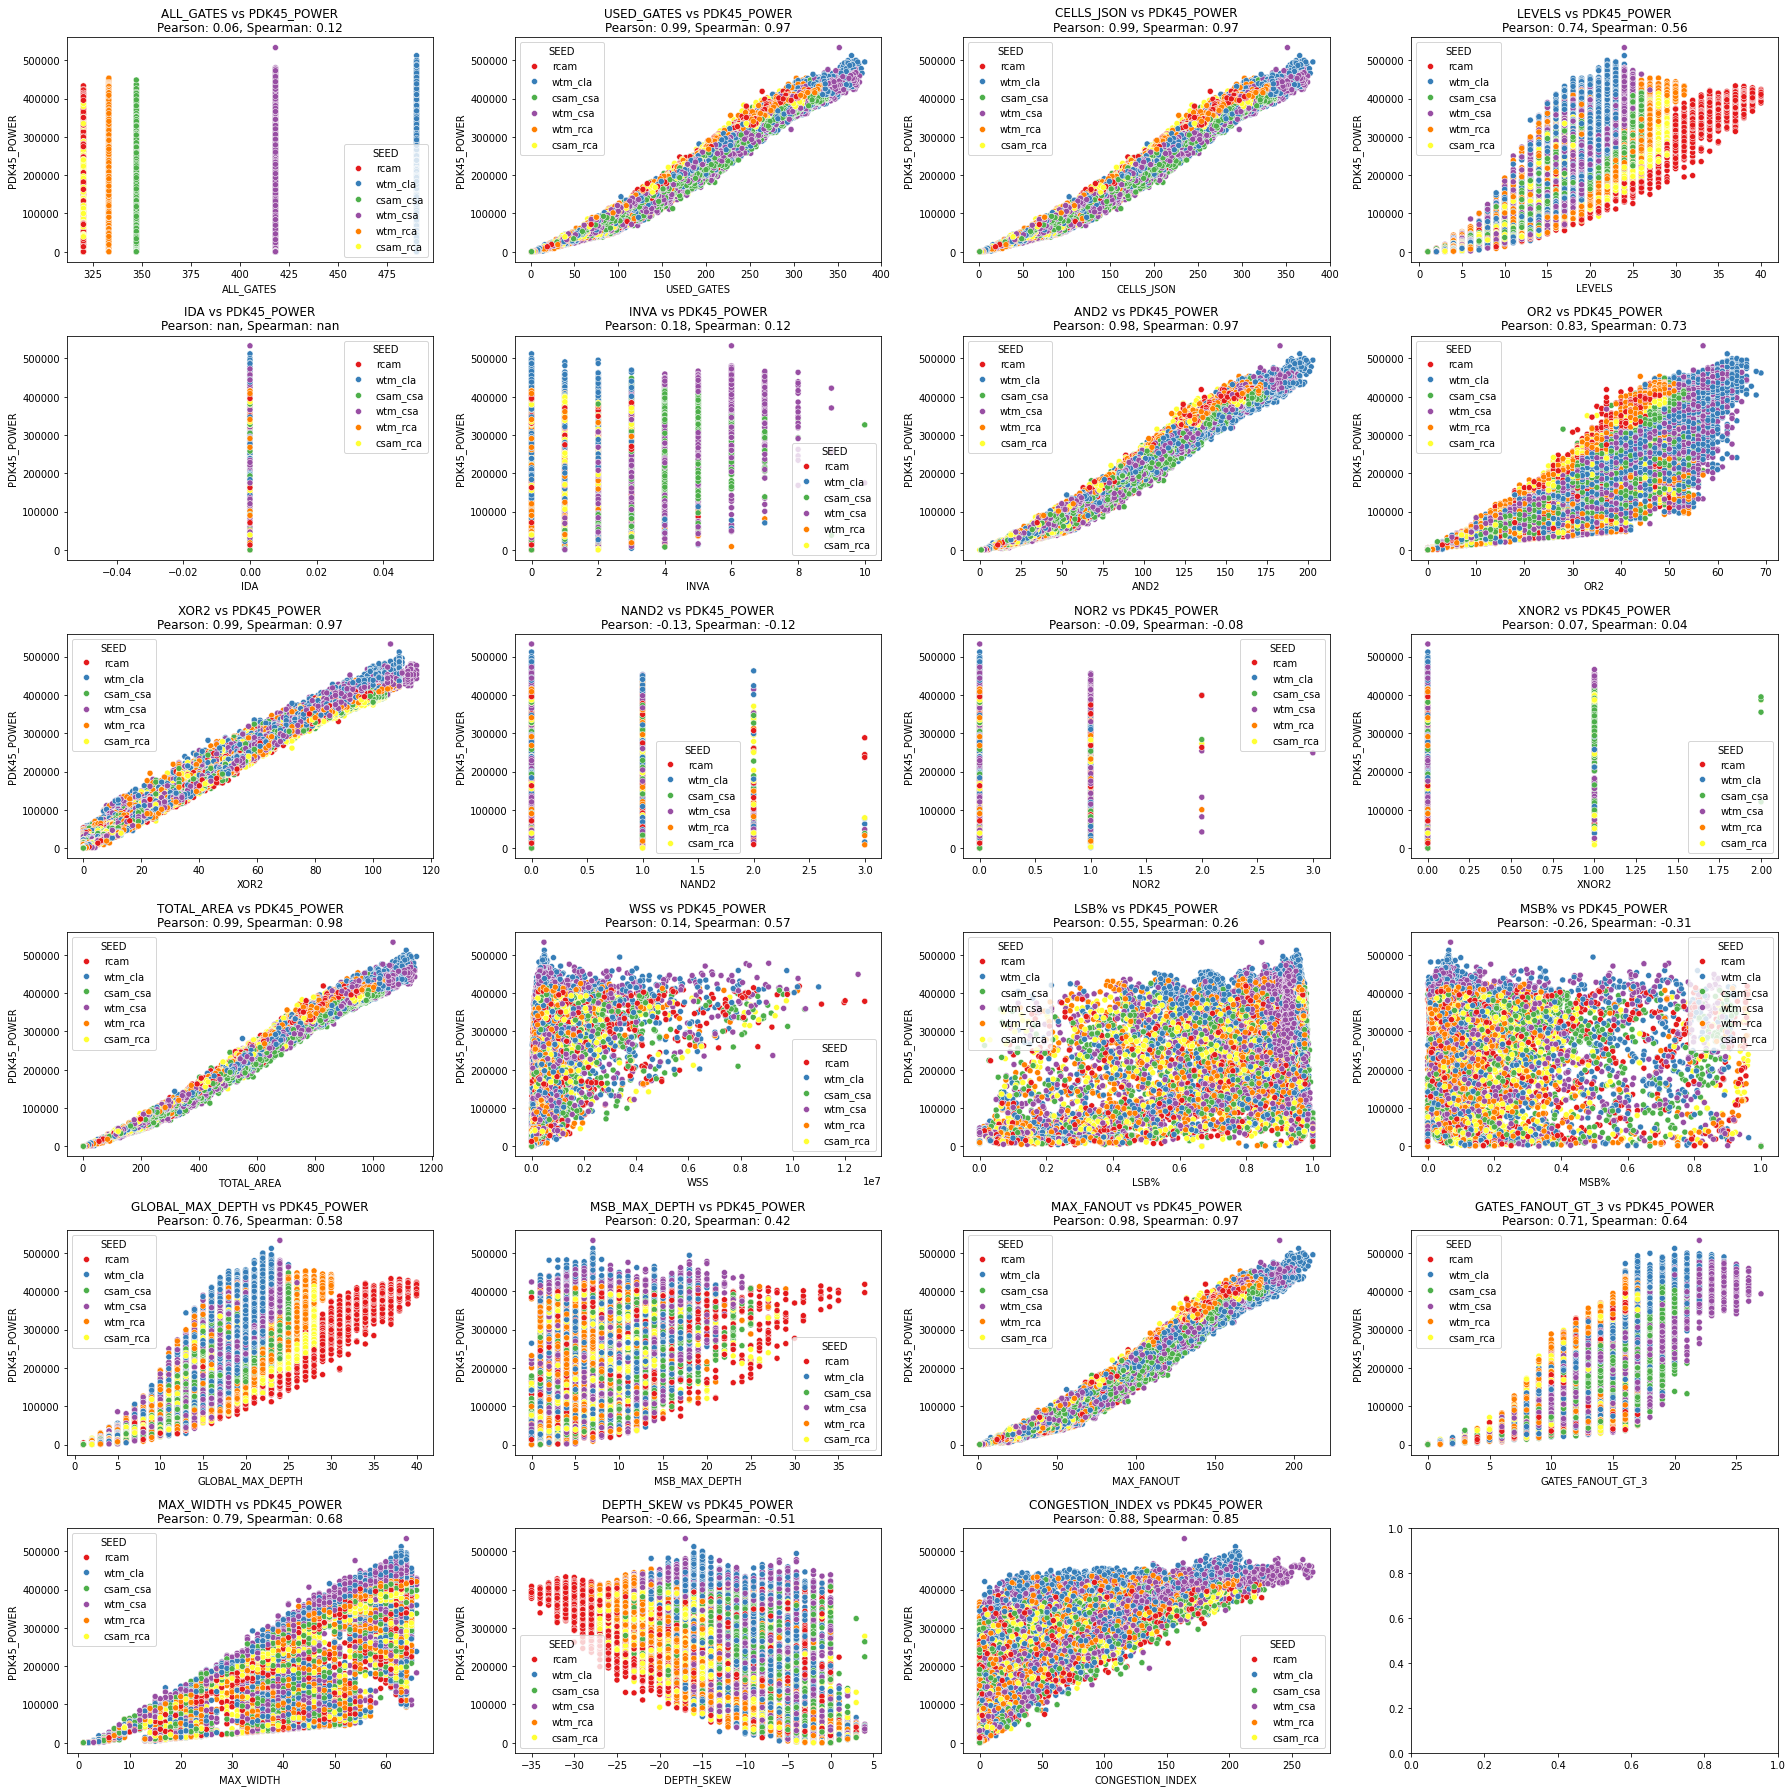

In [14]:
# Scatter plot of all fast features correlating with PDK45_POWER
# make in into a grid of plots
# calculate Pearson and spearman correlations and display them in the title of each plot

fig, axes = plt.subplots(6, 4, figsize=(25, 25))
axes = axes.flatten()

for i, feature in enumerate(fast_features):
    sns.scatterplot(data=df, x=feature, y='PDK45_POWER', hue='SEED', palette='Set1', ax=axes[i])
    pearson_corr = df[feature].corr(df['PDK45_POWER'])
    spearman_corr = df[feature].corr(df['PDK45_POWER'], method='spearman')
    axes[i].set_title(f'{feature} vs PDK45_POWER\nPearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('PDK45_POWER')
plt.tight_layout()
plt.show()  



In [15]:
df.drop(columns=['CELLS_JSON', 'ALL_GATES'], inplace=True)

In [16]:
fast_features.remove('ALL_GATES')
fast_features.remove('CELLS_JSON')

In [17]:
# Calculate correlation for fast features with PDK45_POWER
correlations = {}
for feature in fast_features:
    pearson_corr = df[feature].corr(df['PDK45_POWER'])
    spearman_corr = df[feature].corr(df['PDK45_POWER'], method='spearman')
    correlations[feature] = {'Pearson': pearson_corr, 'Spearman': spearman_corr}
correlations_df = pd.DataFrame(correlations).T
correlations_df.sort_values(by='Pearson', ascending=False, inplace=True)
correlations_df

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


,Pearson,Spearman
TOTAL_AREA,0.991676,0.975732
XOR2,0.988959,0.973439
USED_GATES,0.986119,0.967741
AND2,0.983384,0.965936
MAX_FANOUT,0.982666,0.965800
CONGESTION_INDEX,0.878465,0.849378
OR2,0.830868,0.726510
MAX_WIDTH,0.787240,0.681325
GLOBAL_MAX_DEPTH,0.758978,0.575281
LEVELS,0.744896,0.556006


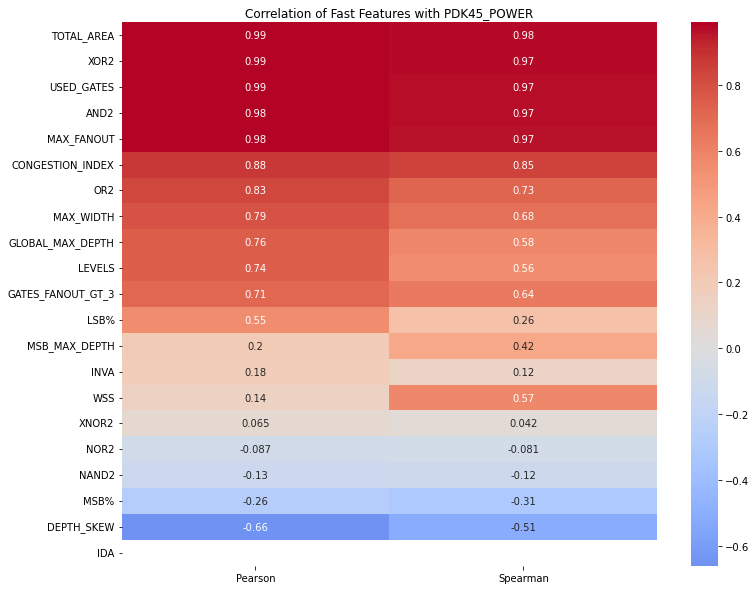

In [18]:
# show correlations as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlations_df, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Fast Features with PDK45_POWER')   
plt.show()

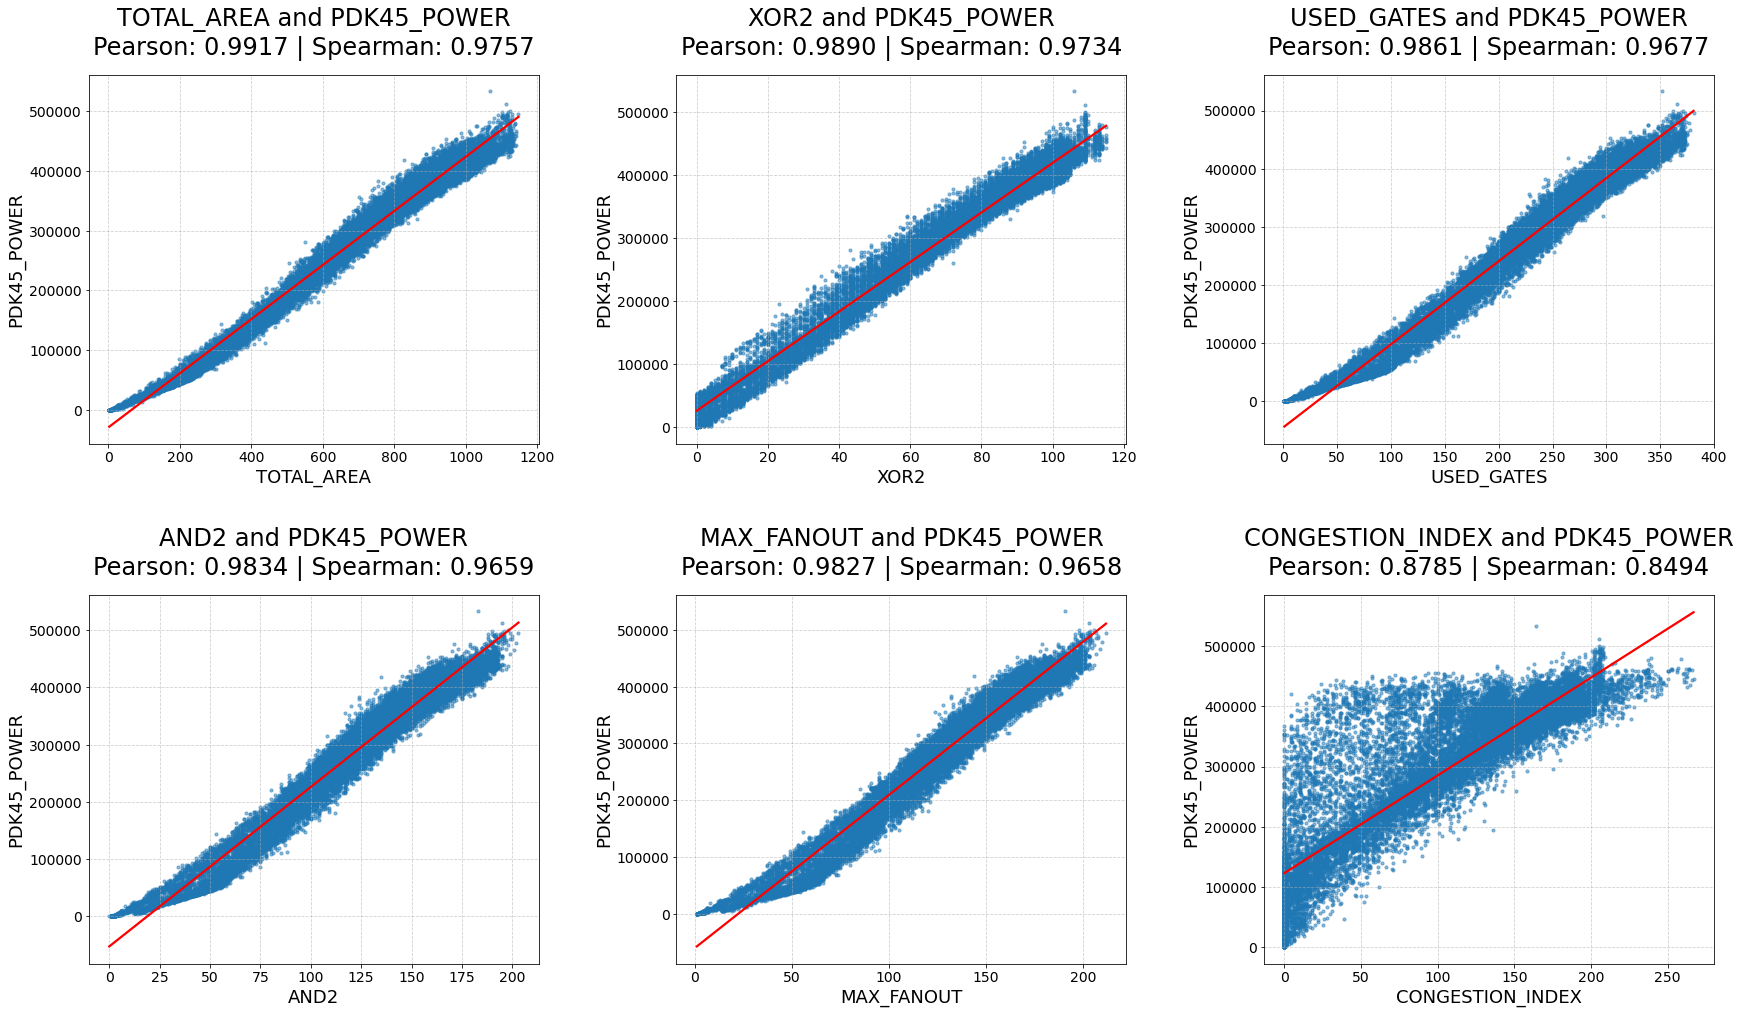

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# --- 1. SETUP ---
# Your specific features and target
top_6_features = ['TOTAL_AREA', 'XOR2','USED_GATES', 'AND2', 'MAX_FANOUT', 'CONGESTION_INDEX']
target = 'PDK45_POWER'

# --- 2. CREATE PLOT GRID ---
fig, axes = plt.subplots(2, 3, figsize=(25, 15))
axes = axes.flatten()

for i, feature in enumerate(top_6_features):
    # Calculate Correlations
    p_corr, _ = pearsonr(df[feature], df[target])
    s_corr, _ = spearmanr(df[feature], df[target])
    
    # Plotting
    sns.regplot(
        data=df, 
        x=feature, 
        y=target, 
        ax=axes[i],
        scatter_kws={'alpha':0.5, 's':10},
        line_kws={'color':'red', 'label':'Linear Fit'}
    )
    
    # --- MODIFIED SECTION: ONLY FONT SIZES ---
    title_text = f"{feature} and PDK45_POWER\nPearson: {p_corr:.4f} | Spearman: {s_corr:.4f}"
    
    # Massive titles for visibility
    axes[i].set_title(title_text, fontsize=24, pad=20)
    
    # Larger axis labels
    axes[i].set_xlabel(feature, fontsize=18)
    axes[i].set_ylabel(target, fontsize=18)
    
    # Larger tick marks (numbers on the axes)
    axes[i].tick_params(labelsize=14)
    
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(pad=4.0)
plt.show()

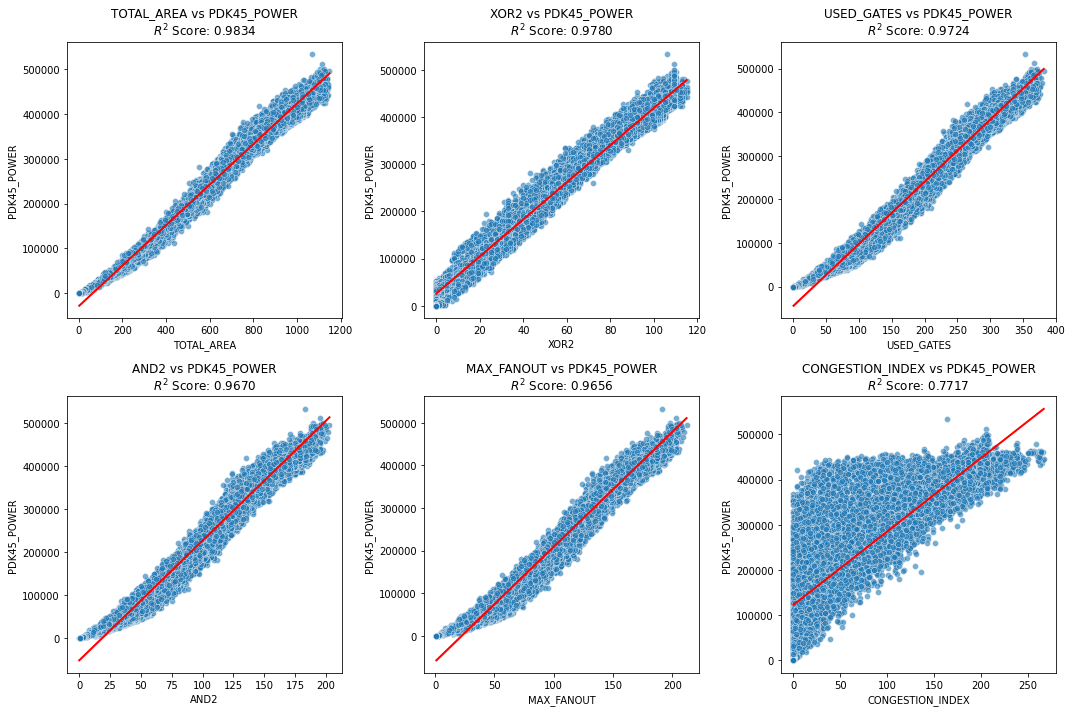

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Define your data (Example list of best features)
top_6_features = ['TOTAL_AREA', 'XOR2','USED_GATES', 'AND2', 'MAX_FANOUT', 'CONGESTION_INDEX']
target = 'PDK45_POWER'

# 2. Setup the figure grid (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()  

for i, feature in enumerate(top_6_features):
    # Prepare data (handle missing values if necessary)
    data = df[[feature, target]].dropna()
    X = data[[feature]].values
    y = data[target].values
    
    # 3. Perform Linear Regression
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    # 4. Plotting
    sns.scatterplot(x=X.flatten(), y=y, ax=axes[i], alpha=0.6)
    sns.lineplot(x=X.flatten(), y=y_pred, ax=axes[i], color='red', linewidth=2)
    
    # 5. Formatting
    axes[i].set_title(f"{feature} vs {target}\n$R^2$ Score: {r2:.4f}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

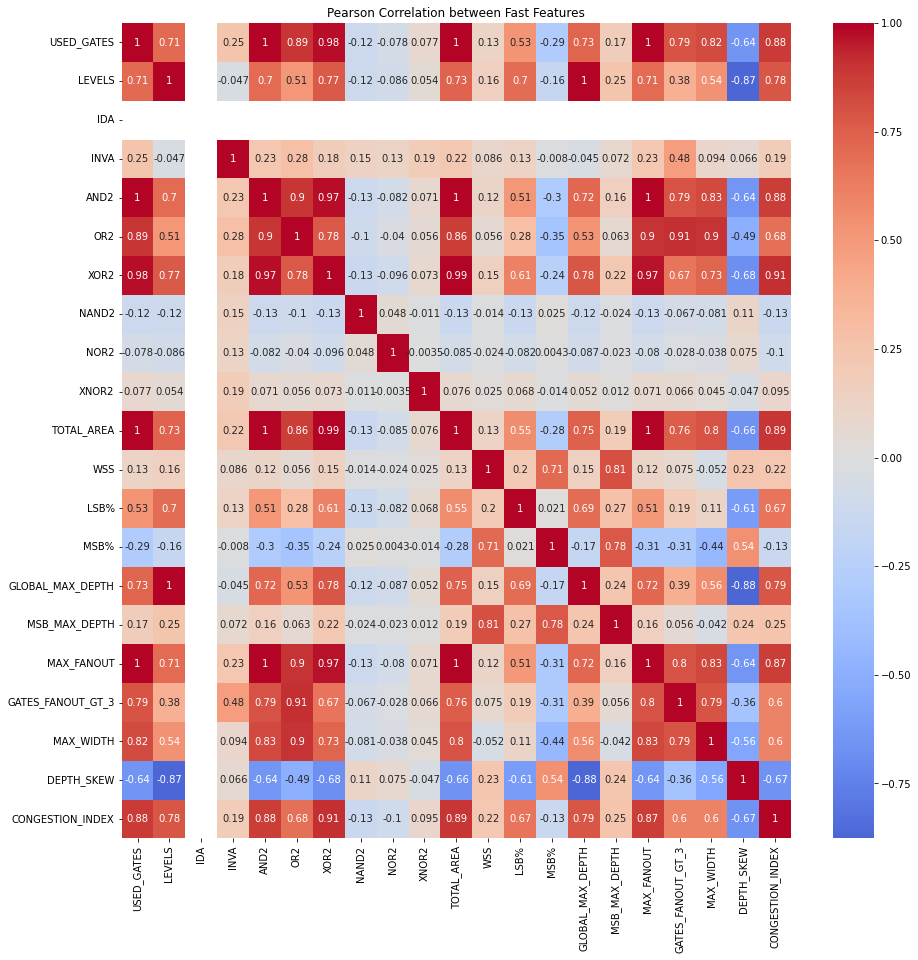

In [20]:
# Correlation matrix of fast features
corr_matrix_pear = df[fast_features].corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix_pear, annot=True, cmap='coolwarm', center=0)
plt.title('Pearson Correlation between Fast Features')
plt.show()

--- FEATURE LEADERBOARD (Sorted by lowest RMSE) ---
          Feature         RMSE     MAPE
       TOTAL_AREA 16091.790497 0.303708
             XOR2 18521.178946 0.318435
       USED_GATES 20752.069984 0.472911
             AND2 22688.405858 0.529244
       MAX_FANOUT 23169.597781 0.604910
 CONGESTION_INDEX 59716.408352 1.424097
              OR2 69547.881691 0.951392
        MAX_WIDTH 77068.690118 0.997206
 GLOBAL_MAX_DEPTH 81376.725415 0.696330
           LEVELS 83384.569760 0.730693
GATES_FANOUT_GT_3 87643.058179 1.094605
       DEPTH_SKEW 93709.366787 1.724267


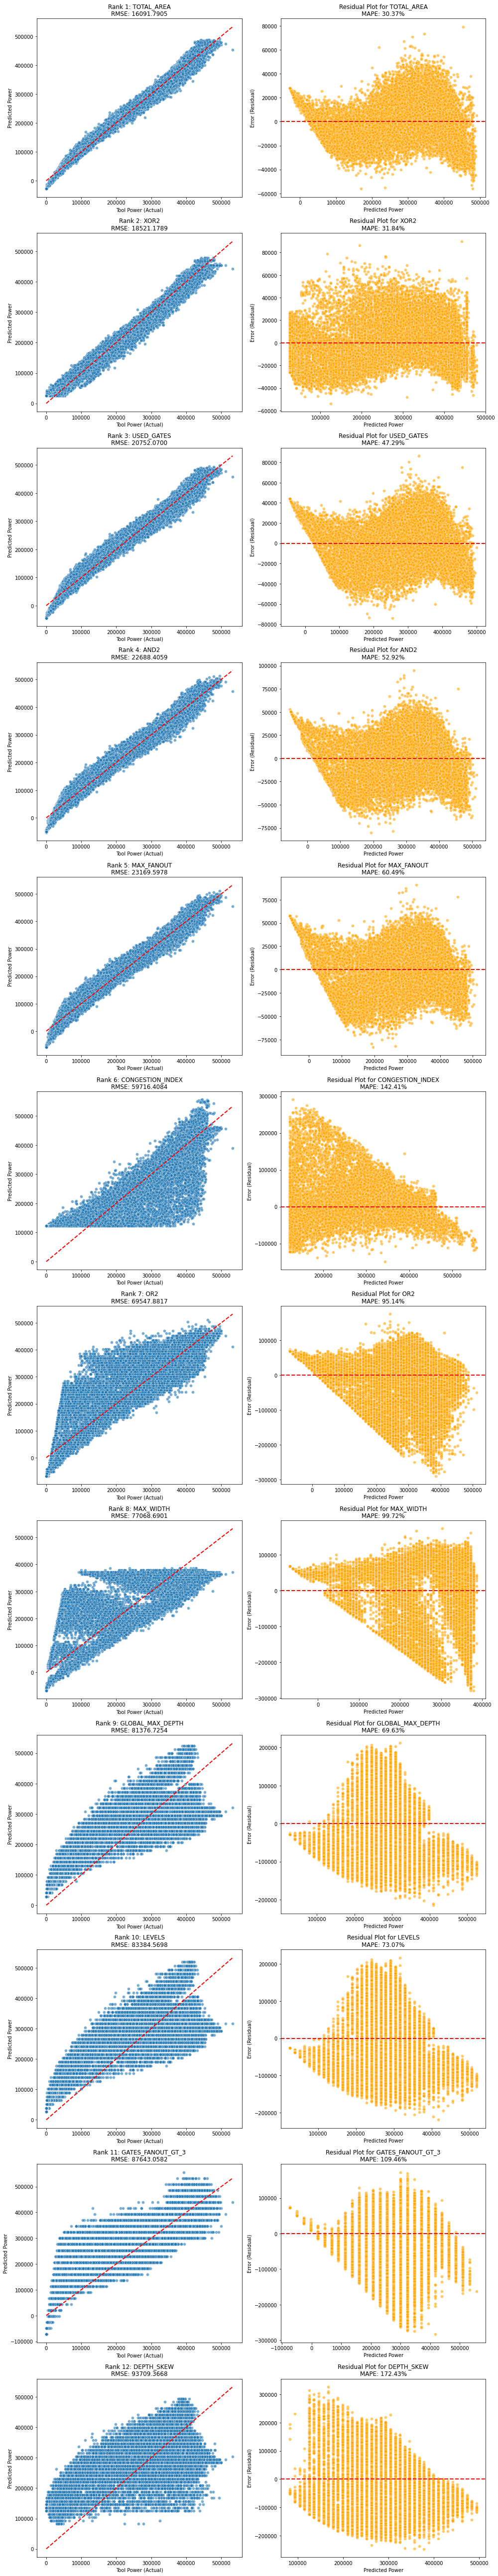

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- 1. SETUP DATA ---
# Replace this with your actual dataframe loading: df = pd.read_csv('your_data.csv')
# Assuming 'Power' is your target column
target = 'PDK45_POWER'
features_to_test = ['USED_GATES', 'AND2', 'OR2', 'XOR2', 'TOTAL_AREA', 'GLOBAL_MAX_DEPTH', 'MAX_FANOUT', 'GATES_FANOUT_GT_3', 'MAX_WIDTH', 'DEPTH_SKEW', 'CONGESTION_INDEX', 'LEVELS']

results = []

# --- 2. CALCULATE METRICS ---
for feature in features_to_test:
    # Prepare data (reshape for sklearn)
    X = df[[feature]].values
    y = df[target].values
    
    # Fit Linear Model
    model = LinearRegression()
    model.fit(X, y)
    predictions = model.predict(X)
    
    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y, predictions))
    mape = mean_absolute_percentage_error(y, predictions)
    residuals = y - predictions
    
    results.append({
        'Feature': feature,
        'RMSE': rmse,
        'MAPE': mape,
        'Residuals': residuals,
        'Predictions': predictions,
        'Actual': y
    })

# --- 3. CREATE SORTED LEADERBOARD ---
# Convert results list to a DataFrame and sort by RMSE (ascending)
leaderboard = pd.DataFrame(results).sort_values(by='RMSE')

# Display the numerical leaderboard
print("--- FEATURE LEADERBOARD (Sorted by lowest RMSE) ---")
print(leaderboard[['Feature', 'RMSE', 'MAPE']].to_string(index=False))

# --- 4. PLOTTING (Sorted Order) ---
# We use the order from the leaderboard to plot the best features first
sorted_features = leaderboard['Feature'].tolist()
fig, axes = plt.subplots(len(sorted_features), 2, figsize=(14, 6 * len(sorted_features)))

for i, feature_name in enumerate(sorted_features):
    # Retrieve result for this specific feature
    res = next(item for item in results if item["Feature"] == feature_name)
    
    # Plot 1: Regression Fit (Actual vs Predicted)
    sns.scatterplot(x=res['Actual'], y=res['Predictions'], ax=axes[i, 0], alpha=0.6)
    axes[i, 0].plot([res['Actual'].min(), res['Actual'].max()], 
                    [res['Actual'].min(), res['Actual'].max()], 'r--', lw=2)
    axes[i, 0].set_title(f"Rank {i+1}: {feature_name}\nRMSE: {res['RMSE']:.4f}")
    axes[i, 0].set_xlabel("Tool Power (Actual)")
    axes[i, 0].set_ylabel("Predicted Power")
    
    # Plot 2: Residual Analysis (Error Pattern)
    sns.scatterplot(x=res['Predictions'], y=res['Residuals'], ax=axes[i, 1], color='orange', alpha=0.6)
    axes[i, 1].axhline(0, color='red', linestyle='--', lw=2)
    axes[i, 1].set_title(f"Residual Plot for {feature_name}\nMAPE: {res['MAPE']:.2%}")
    axes[i, 1].set_xlabel("Predicted Power")
    axes[i, 1].set_ylabel("Error (Residual)")

plt.tight_layout()
plt.show()

--- Regression Results for TOTAL_AREA ---
Model: Power = (452.1225 * TOTAL_AREA) + -28825.8679
R² Score: 0.9834 (This explains 98.3% of power variance)


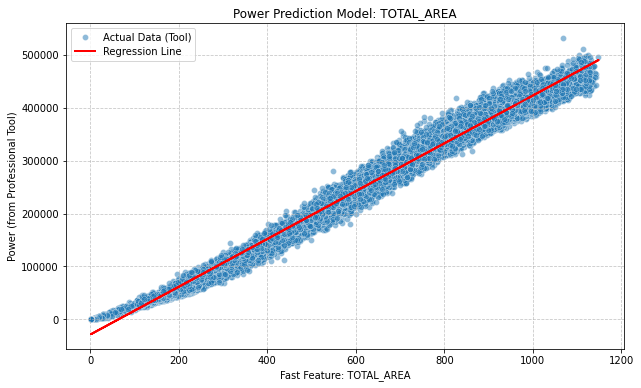

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. SELECT THE WINNER ---
best_feature = 'TOTAL_AREA' 
target = 'PDK45_POWER'

X = df[[best_feature]].values
y = df[target].values

# --- 2. TRAIN THE REGRESSION MODEL ---
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, model.predict(X))

print(f"--- Regression Results for {best_feature} ---")
print(f"Model: Power = ({slope:.4f} * {best_feature}) + {intercept:.4f}")
print(f"R² Score: {r2:.4f} (This explains {r2*100:.1f}% of power variance)")

# --- 3. PREDICTION & VISUALIZATION ---
df['Predicted_Power'] = model.predict(X)

plt.figure(figsize=(10, 6))
# Scatter plot of the raw data
sns.scatterplot(data=df, x=best_feature, y=target, alpha=0.5, label='Actual Data (Tool)')
# The Regression Line
plt.plot(df[best_feature], df['Predicted_Power'], color='red', linewidth=2, label='Regression Line')

plt.title(f'Power Prediction Model: {best_feature}')
plt.xlabel(f'Fast Feature: {best_feature}')
plt.ylabel('Power (from Professional Tool)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


--- Regression Results for XOR2 ---
Model: Power = (3930.2237 * XOR2) + 26338.3307
R² Score: 0.9780 (This explains 97.8% of power variance)


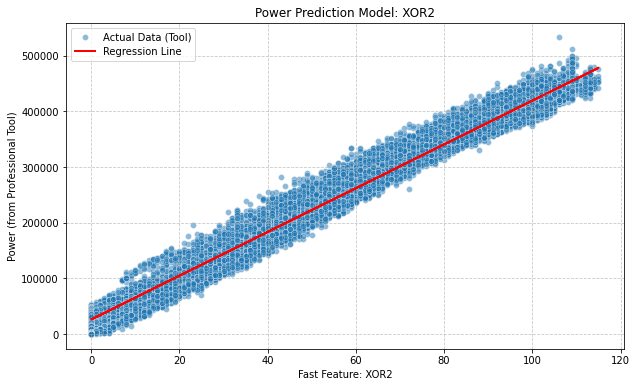

In [23]:
# --- 1. SELECT THE WINNER ---
best_feature = 'XOR2' 
target = 'PDK45_POWER'

X = df[[best_feature]].values
y = df[target].values

# --- 2. TRAIN THE REGRESSION MODEL ---
model = LinearRegression()
model.fit(X, y)

# Extract the "Physics" of your multiplier
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, model.predict(X))

print(f"--- Regression Results for {best_feature} ---")
print(f"Model: Power = ({slope:.4f} * {best_feature}) + {intercept:.4f}")
print(f"R² Score: {r2:.4f} (This explains {r2*100:.1f}% of power variance)")

# --- 3. PREDICTION & VISUALIZATION ---
df['Predicted_Power'] = model.predict(X)

plt.figure(figsize=(10, 6))
# Scatter plot of the raw data
sns.scatterplot(data=df, x=best_feature, y=target, alpha=0.5, label='Actual Data (Tool)')
# The Regression Line
plt.plot(df[best_feature], df['Predicted_Power'], color='red', linewidth=2, label='Regression Line')

plt.title(f'Power Prediction Model: {best_feature}')
plt.xlabel(f'Fast Feature: {best_feature}')
plt.ylabel('Power (from Professional Tool)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- Regression Results for AND2 ---
Model: Power = (2787.8400 * AND2) + -52652.1864
R² Score: 0.9670 (This explains 96.7% of power variance)


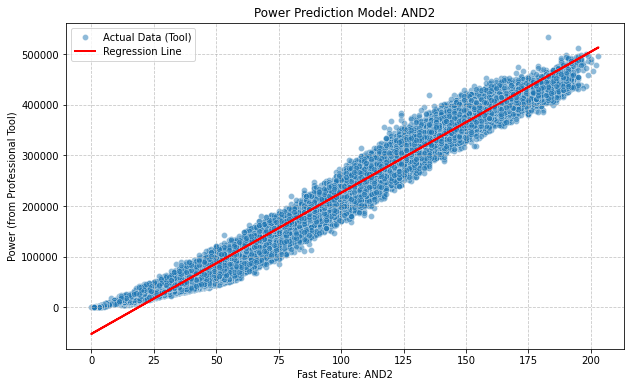

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. SELECT THE WINNER ---
# Based on your previous RMSE test, put the best feature name here
best_feature = 'AND2' 
target = 'PDK45_POWER'

X = df[[best_feature]].values
y = df[target].values

# --- 2. TRAIN THE REGRESSION MODEL ---
model = LinearRegression()
model.fit(X, y)

# Extract the "Physics" of your multiplier
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, model.predict(X))

print(f"--- Regression Results for {best_feature} ---")
print(f"Model: Power = ({slope:.4f} * {best_feature}) + {intercept:.4f}")
print(f"R² Score: {r2:.4f} (This explains {r2*100:.1f}% of power variance)")

# --- 3. PREDICTION & VISUALIZATION ---
df['Predicted_Power'] = model.predict(X)

plt.figure(figsize=(10, 6))
# Scatter plot of the raw data
sns.scatterplot(data=df, x=best_feature, y=target, alpha=0.5, label='Actual Data (Tool)')
# The Regression Line
plt.plot(df[best_feature], df['Predicted_Power'], color='red', linewidth=2, label='Regression Line')

plt.title(f'Power Prediction Model: {best_feature}')
plt.xlabel(f'Fast Feature: {best_feature}')
plt.ylabel('Power (from Professional Tool)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 4. EXPORT FOR FUTURE USE ---
# You can now use this simple function instead of the professional tool!
def estimate_power(feature_value):
    return (slope * feature_value) + intercept

--- Regression Results for USED_GATES ---
Model: Power = (1428.9348 * USED_GATES) + -45053.3996
R² Score: 0.9724 (This explains 97.2% of power variance)


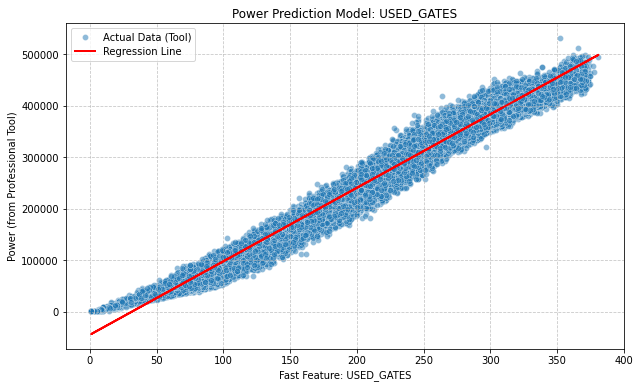

In [25]:
# --- 1. SELECT THE WINNER ---
# Based on your previous RMSE test, put the best feature name here
best_feature = 'USED_GATES' 
target = 'PDK45_POWER'

X = df[[best_feature]].values
y = df[target].values

# --- 2. TRAIN THE REGRESSION MODEL ---
model = LinearRegression()
model.fit(X, y)

# Extract the "Physics" of your multiplier
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, model.predict(X))

print(f"--- Regression Results for {best_feature} ---")
print(f"Model: Power = ({slope:.4f} * {best_feature}) + {intercept:.4f}")
print(f"R² Score: {r2:.4f} (This explains {r2*100:.1f}% of power variance)")

# --- 3. PREDICTION & VISUALIZATION ---
df['Predicted_Power'] = model.predict(X)

plt.figure(figsize=(10, 6))
# Scatter plot of the raw data
sns.scatterplot(data=df, x=best_feature, y=target, alpha=0.5, label='Actual Data (Tool)')
# The Regression Line
plt.plot(df[best_feature], df['Predicted_Power'], color='red', linewidth=2, label='Regression Line')

plt.title(f'Power Prediction Model: {best_feature}')
plt.xlabel(f'Fast Feature: {best_feature}')
plt.ylabel('Power (from Professional Tool)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 4. EXPORT FOR FUTURE USE ---
# You can now use this simple function instead of the professional tool!
def estimate_power(feature_value):
    return (slope * feature_value) + intercept

--- Model Validation Results ---
Test RMSE: 20912.4906
Test R²: 0.9718


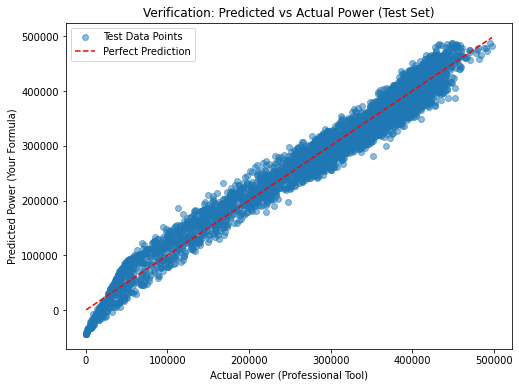

In [26]:
from sklearn.model_selection import train_test_split

# --- 1. PREPARE SPLIT ---
X = df[[best_feature]].values
y = df[target].values

# 80% to train the formula, 20% to hide and test later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. TRAIN ON 80% ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- 3. EVALUATE ON THE HIDDEN 20% ---
y_pred_test = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"--- Model Validation Results ---")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")

# --- 4. VISUALIZE THE TEST PERFORMANCE ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Test Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.title(f'Verification: Predicted vs Actual Power (Test Set)')
plt.xlabel('Actual Power (Professional Tool)')
plt.ylabel('Predicted Power (Your Formula)')
plt.legend()
plt.show()